In [11]:
%load_ext autoreload
%autoreload 2
from RWC import RWC_reduction, compute_rwc
import matplotlib.pyplot as plt
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
new_edges = RWC_reduction(graph_file='../../../output/results-theta=0.5/Referendum_/graph.gml', k=100)
# print(new_edges)

RED TOPK:  65
BLUE TOPK:  219
RWC computed:  0.5859487927692599
LEN CANDIDATES:  1000
Number of cores:  16
Number of cores used:  1
Not parallelizing...


Updating RWC: 100%|██████████| 1000/1000 [03:13<00:00,  5.18it/s]


FINAL SELECTED LEN CANDIDATES:  100
NEW RWC SCORE:  0.5410841289879986


In [51]:
G = nx.read_gml('../../../output/results-theta=0.5/Referendum_/graph.gml')
rwc_score = compute_rwc(G)
print(rwc_score)
G.add_edges_from([(str(i[0]), str(i[1])) for i in new_edges])
rwc_score = compute_rwc(G)
print(rwc_score)

0.5859487927692599
0.5410841289879986


In [7]:
def draw_graph(graph, new_edges):
    # draw graph G, with grey-colored edges and draw new_edges in red, and with thicker lines
    plt.figure(figsize=(10, 10))
    
    # Create a copy of the graph to avoid modifying the original
    graph_copy = graph.copy()
    
    # Extract the edges without weights
    simple_new_edges = [(u, v) for u, v in new_edges]
    
    # Add the new edges to the graph copy
    graph_copy.add_edges_from(simple_new_edges)
    pos = nx.spring_layout(graph)
    
    # Create separate edge lists
    old_edges = [e for e in graph_copy.edges() if e not in simple_new_edges and (e[1], e[0]) not in simple_new_edges]
    highlight_edges = [e for e in graph_copy.edges() if e in simple_new_edges or (e[1], e[0]) in simple_new_edges]
    
    # Use matplotlib directly to avoid the NetworkX issue
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Draw nodes
    nx.draw_networkx_nodes(graph_copy, pos, node_size=50, ax=ax, node_color='black')
    
    # Draw old edges
    for edge in old_edges:
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        ax.plot([x0, x1], [y0, y1], 'grey', alpha=0.5, linewidth=1.0)
    
    # Draw new edges
    for edge in highlight_edges:
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        ax.plot([x0, x1], [y0, y1], 'blue', alpha=0.5, linewidth=1.0)
    
    plt.title("Graph with new edges highlighted")
    plt.axis('off')  # Turn off the axis
    plt.show()

<Figure size 1000x1000 with 0 Axes>

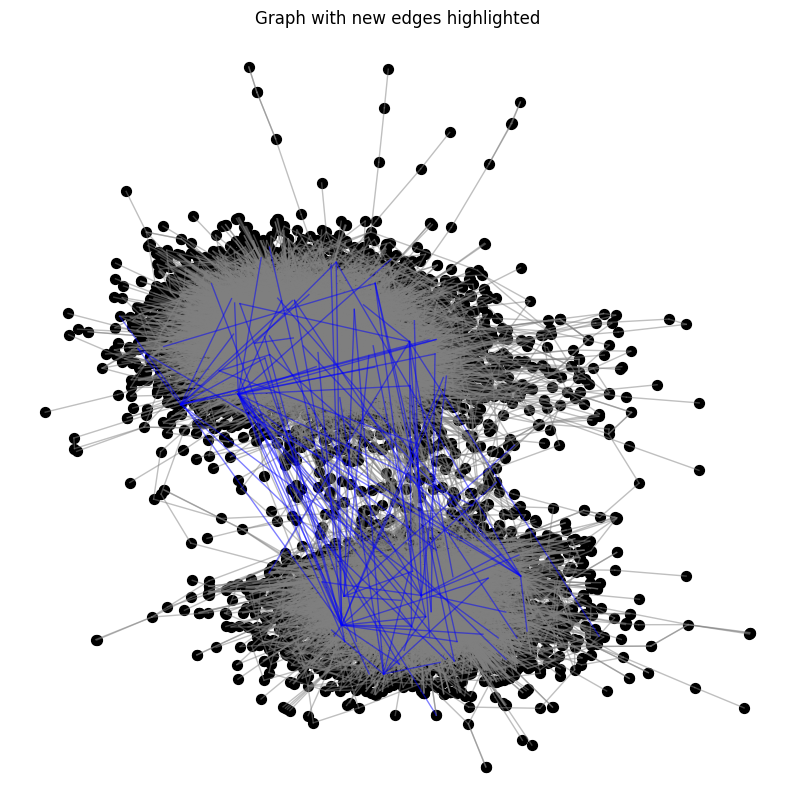

In [8]:
G = nx.read_gml('../../../output/results-theta=0.5/Gun/graph.gml')
# convert node labels from string to int
G = nx.convert_node_labels_to_integers(G, first_label=0)
draw_graph(G, new_edges)